# ZenGuard UEBA Anomaly Detection

This notebook implements the User and Entity Behavior Analytics (UEBA) component of the ZenGuard Framework using the Isolation Forest algorithm.

## System Integration Data Flow

### 1. What Output Comes from the SIEM?
- **Alerts and Correlated Events:** SIEM acts as the central monitoring hub. It aggregates logs from firewalls, IDS, Identity Providers (IdP), and Endpoint Detection and Response (EDR).
- **Parsed Metadata:** Source and destination IPs, timestamps, activity types (e.g., login attempts, external connections), and user/device identifiers.
- **Event Triggers:** SIEM forwards flagged events to the Listener module for UEBA analysis.

### 2. What Input UEBA Needs?
UEBA requires normalized behavioral session telemetry to establish baselines and detect deviations. Features include:
- `session_duration` (numeric)
- `failed_logins` (count)
- `access_time` (hour)
- `device_trust_score` (normalized)
- `privilege_change_attempted` (binary)
- `external_connection` (binary)
- `MFA_bypassed` (binary)

*Note: In this implementation, we use the CICIDS2017 dataset which simulates network flow characteristics to demonstrate anomaly detection as requested.*

### 3. What Output UEBA Produces?
- **Anomaly Risk Score:** A discrete risk score. A score below the anomaly threshold (anomaly metric isolation) generates a high risk score (i.e. 95). Normal sessions receive a lower risk score (i.e. 50).
- **Contextual Flag:** Identified malicious activities vs. benign operations.

### 4. What Inputs SOAR Needs?
- **Source and Destination IPs**
- **UEBA Risk Score** (e.g. 95)
- **Trigger Action Metadata:** Context such as whether to enforce MFA, block IP via Firewall API, or isolate an endpoint.

In [1]:
!pip install kagglehub pandas numpy scikit-learn joblib matplotlib seaborn

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import joblib

# Set plotting style
plt.style.use('default')
sns.set_theme(style="whitegrid")

In [3]:
# Stage 1: Data Ingestion
print('Downloading dataset...')
path = kagglehub.dataset_download("asthana12/cicids2017")
print("Path to dataset files:", path)

# Find the CSV file in the downloaded path
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
if csv_files:
    data_path = csv_files[0]
    print(f"Loading {data_path}...")
    # Load a sample to keep memory usage low for demonstration
    df = pd.read_csv(data_path, nrows=100000)
    print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print("No CSV files found in the dataset path.")

100%|██████████| 230M/230M [00:01<00:00, 157MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asthana12/cicids2017/versions/1
Loading /root/.cache/kagglehub/datasets/asthana12/cicids2017/versions/1/Friday-WorkingHours-Afternoon-PortScan.csv...
Loaded 100000 rows and 79 columns.


In [4]:
# Stage 2: Data Preprocessing
print("Cleaning columns...")
df.columns = df.columns.str.strip()

# Drop rows with infinite values and NAs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Select numerical features for Isolation Forest
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Label' in numeric_features:
    numeric_features.remove('Label') # Avoid target leakage

print(f"Selected {len(numeric_features)} numerical features for anomaly detection.")

X = df[numeric_features]
y = df['Label'] if 'Label' in df.columns else None

# Preprocessing pipeline
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

Cleaning columns...
Selected 78 numerical features for anomaly detection.


In [5]:
# Stage 3: Data Segregation (Training and Testing)
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y if y is not None else None)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Splitting data into training and testing sets...
Training set size: 69954 samples
Testing set size: 29981 samples


In [6]:
# Stage 4: Model Training (UEBA Isolation Forest)
print("Building Isolation Forest Model Pipeline...")
ueba_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1))
])

print("Training the UEBA Anomaly Detection Model on Training Set...")
ueba_model.fit(X_train)
print("Model training complete.")

Building Isolation Forest Model Pipeline...
Training the UEBA Anomaly Detection Model on Training Set...
Model training complete.


In [7]:
# Stage 5: Prediction and Risk Scoring on Testing Set
print("Generating predictions and anomaly scores for Testing Set...")
# Predict: -1 for outliers/anomalies, 1 for inliers/normal
predictions = ueba_model.predict(X_test)
anomaly_scores_raw = ueba_model.decision_function(X_test)

# Map to Risk Scores: Anomaly (-1) -> 95 Risk, Normal (1) -> 50 Risk
risk_scores = np.where(predictions == -1, 95, 50)

# Create a results DataFrame based on X_test
results_df = X_test.copy()
if y_test is not None:
    results_df['Actual_Label'] = y_test
results_df['Predicted_Class'] = predictions
results_df['UEBA_Risk_Score'] = risk_scores
results_df['UEBA_Anomaly_Score'] = anomaly_scores_raw
results_df['Is_Anomaly'] = predictions == -1

high_risk_interactions = results_df[results_df['UEBA_Risk_Score'] == 95]
print(f"Detected {len(high_risk_interactions)} anomalous (high-risk) events out of {len(results_df)} total in the test set.")

display(high_risk_interactions.head())

Generating predictions and anomaly scores for Testing Set...
Detected 1454 anomalous (high-risk) events out of 29981 total in the test set.


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Actual_Label,Predicted_Class,UEBA_Risk_Score,UEBA_Anomaly_Score,Is_Anomaly
42176,80,47565542,56,56,4911,60463,1295,0,87.696429,301.060122,...,14993,1.000000e+07,8.043330e+03,10000000,10000000,BENIGN,-1,95,-0.029084,True
7401,443,115890661,27,31,808,34497,324,0,29.925926,72.443573,...,23628,9.622316e+06,1.337335e+06,10000000,5375729,BENIGN,-1,95,-0.013421,True
32572,80,10605493,23,27,1376,46081,338,0,59.826087,120.790070,...,802675,9.800592e+06,0.000000e+00,9800592,9800592,BENIGN,-1,95,-0.019919,True
46969,80,117989323,116,168,2379,292509,476,0,20.508621,77.570556,...,142975,1.000000e+07,5.453791e+03,10000000,9999304,BENIGN,-1,95,-0.127133,True
20575,80,116922627,93,114,3557,185787,1121,0,38.247312,186.285758,...,14958,1.000000e+07,5.969064e+02,10000000,10000000,BENIGN,-1,95,-0.102141,True


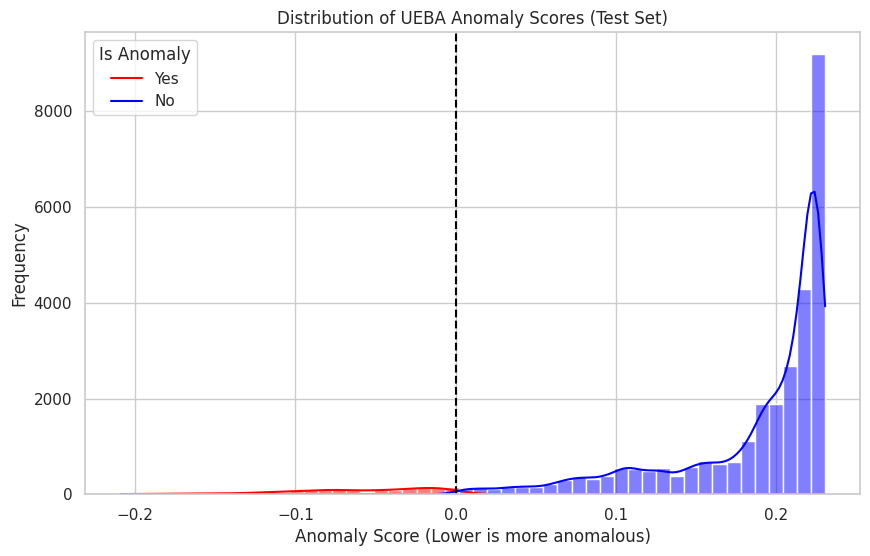

In [8]:
# Stage 6: Visualizations

# 1. Distribution of Anomaly Scores
plt.figure(figsize=(10, 6))
sns.histplot(data=results_df, x='UEBA_Anomaly_Score', hue='Is_Anomaly', bins=50, kde=True, palette={False: 'blue', True: 'red'})
plt.title('Distribution of UEBA Anomaly Scores (Test Set)')
plt.xlabel('Anomaly Score (Lower is more anomalous)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='black', linestyle='--', label='Decision Boundary')
plt.legend(title='Is Anomaly', labels=['Yes', 'No'])
plt.show()

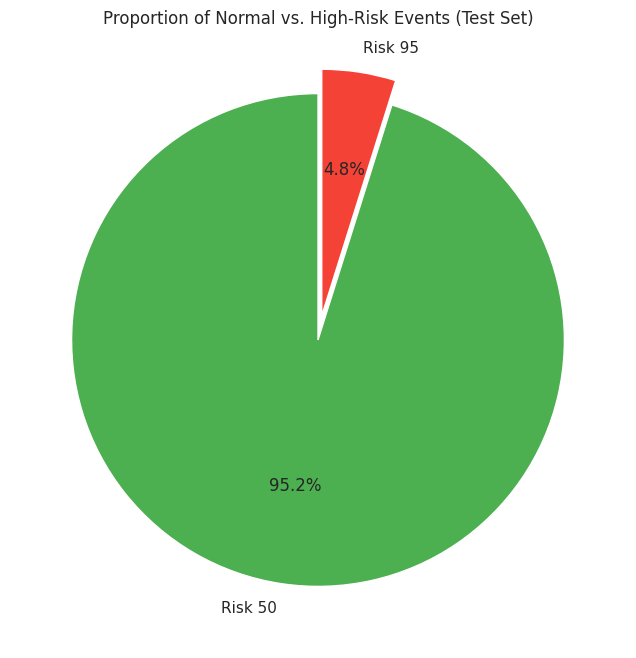

In [9]:
# 2. Pie Chart of Risk Distribution
plt.figure(figsize=(8, 8))
risk_counts = results_df['UEBA_Risk_Score'].value_counts()
labels = [f"Normal (Risk 50)", f"High Risk (Risk 95)"]
# Ensure correct mapping depending on index present
plot_labels = [f"Risk {idx}" for idx in risk_counts.index]
plt.pie(risk_counts, labels=plot_labels, autopct='%1.1f%%', colors=['#4CAF50', '#F44336'], startangle=90, explode=[0.1 if idx == 95 else 0 for idx in risk_counts.index])
plt.title('Proportion of Normal vs. High-Risk Events (Test Set)')
plt.show()

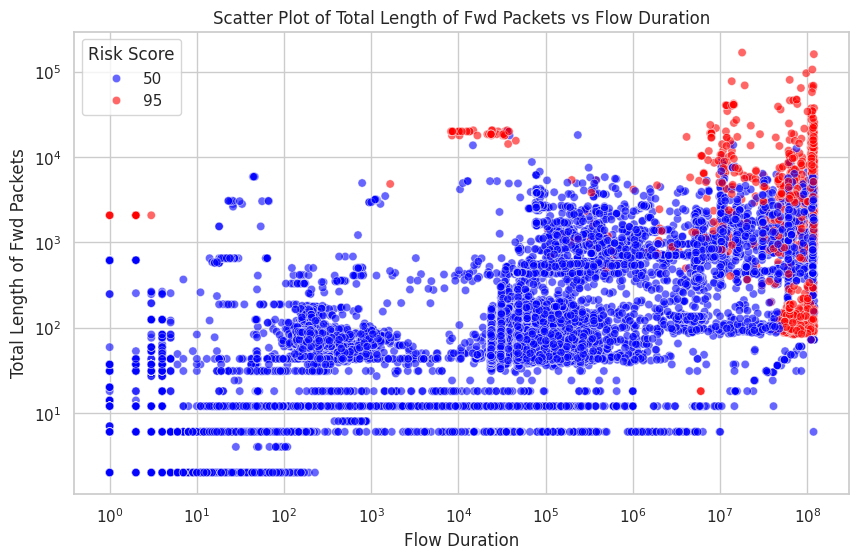

In [10]:
# 3. Scatter Plot of Two Key Features colored by Risk Score
# Use 'Flow Duration' and 'Total Length of Fwd Packets'
features_to_plot = ['Flow Duration', 'Total Length of Fwd Packets']
if all(f in results_df.columns for f in features_to_plot):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=results_df, x=features_to_plot[0], y=features_to_plot[1], hue='UEBA_Risk_Score', palette={50: 'blue', 95: 'red'}, alpha=0.6)
    plt.title(f"Scatter Plot of {features_to_plot[1]} vs {features_to_plot[0]}")
    plt.xlabel(features_to_plot[0])
    plt.ylabel(features_to_plot[1])
    # Log scale is helpful for network traffic
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(title="Risk Score")
    plt.show()
else:
    print(f"Features {features_to_plot} not found for scatter plotting.")

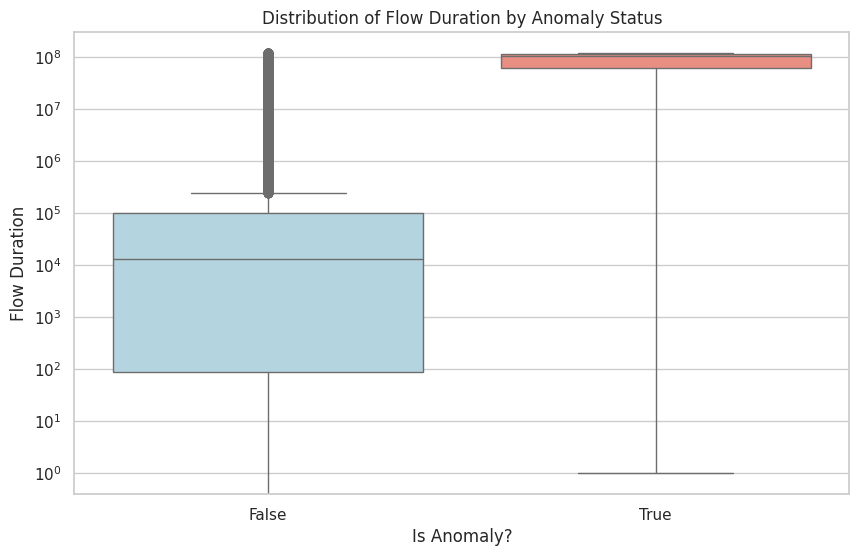

In [15]:
feature_for_boxplot = 'Flow Duration'
if feature_for_boxplot in results_df.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=results_df, x='Is_Anomaly', y=feature_for_boxplot, hue='Is_Anomaly', palette={False: 'lightblue', True: 'salmon'}, legend=False)
    plt.title(f"Distribution of {feature_for_boxplot} by Anomaly Status")
    plt.xlabel('Is Anomaly?')
    plt.ylabel(feature_for_boxplot)
    plt.yscale('log')
    plt.show()

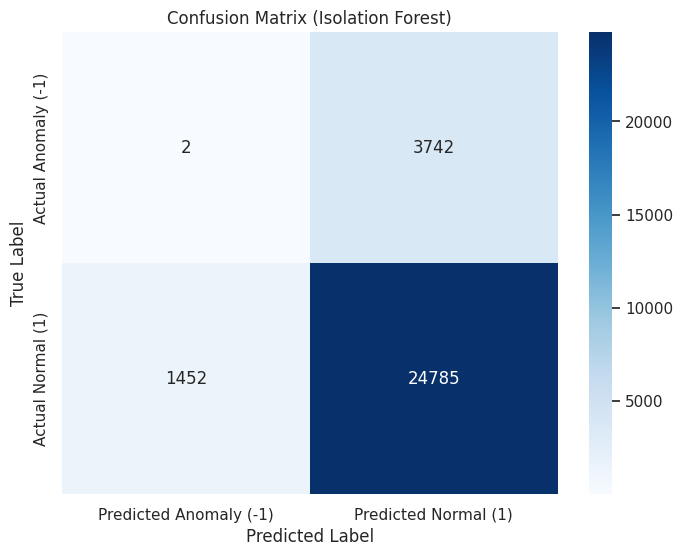


Classification Report:

              precision    recall  f1-score   support

Anomaly (-1)       0.00      0.00      0.00      3744
  Normal (1)       0.87      0.94      0.91     26237

    accuracy                           0.83     29981
   macro avg       0.44      0.47      0.45     29981
weighted avg       0.76      0.83      0.79     29981



In [12]:
# 5. Confusion Matrix (Comparing Predictions to Actual Labels, assuming 'BENIGN' is Normal)
if 'Actual_Label' in results_df.columns:
    # Convert string labels to binary: BENIGN -> 1 (Normal), Others -> -1 (Anomaly)
    y_true_binary = np.where(results_df['Actual_Label'] == 'BENIGN', 1, -1)

    cm = confusion_matrix(y_true_binary, predictions, labels=[-1, 1])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Anomaly (-1)', 'Predicted Normal (1)'],
                yticklabels=['Actual Anomaly (-1)', 'Actual Normal (1)'])
    plt.title('Confusion Matrix (Isolation Forest)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(y_true_binary, predictions, target_names=['Anomaly (-1)', 'Normal (1)']))

In [13]:
# Stage 7: Model Saving for Production Deployment
model_filename = 'zenguard_ueba_model.pkl'
print(f"Saving the updated model to {model_filename}...")
joblib.dump(ueba_model, model_filename)
print("Model successfully saved for SOAR/SIEM integration.")

Saving the updated model to zenguard_ueba_model.pkl...
Model successfully saved for SOAR/SIEM integration.
